# DSP Signal Visualization

Loads the newest `debug_<TIMESTAMP>.csv` from the `data/` dir and plots the raw and filtered acceleration magnitudes from the digital signal processing thread when running `tools/debug_stream.py`. 

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

REPO_ROOT = Path.cwd().resolve().parents[1]
DATA_DIR = REPO_ROOT / "data"
OPTIONAL_DATA_FILEPATH = None

## 1. Load data

In [2]:
candidates = sorted(DATA_DIR.glob("debug_*.csv"), key=lambda p: p.stat().st_mtime)
if not candidates:
    raise FileNotFoundError(f"no debug_*.csv under {DATA_DIR}")

csv_path = OPTIONAL_DATA_FILEPATH if OPTIONAL_DATA_FILEPATH else candidates[-1]
print(f"Using: {csv_path.name}")

df = pd.read_csv(csv_path)
df = df.sort_values(by="timestampUs")

# Remove the 0 timestamp row
df = df.iloc[1:]

# Time axis: seconds from first sample (microsecond timestamps from firmware)
t = (df["timestampUs"] - df["timestampUs"].iloc[0]) * 1e-6

df.head()

Using: debug_20260430_153205.csv


,timestampUs,ax,ay,az,mag,slope
1,189699560,0.001987,-0.000065,0.000030,0.002662,-0.000212
2,189709540,0.002282,0.000647,-0.001036,0.002645,-0.000018
3,189718542,0.000318,-0.000319,0.000415,0.002159,-0.000486
4,189728552,-0.001467,-0.001493,-0.001254,0.002226,0.000067
5,189738532,-0.000357,-0.000382,0.002926,0.002405,0.000179


## 2. Time series: accelerations (ax, ay, az)

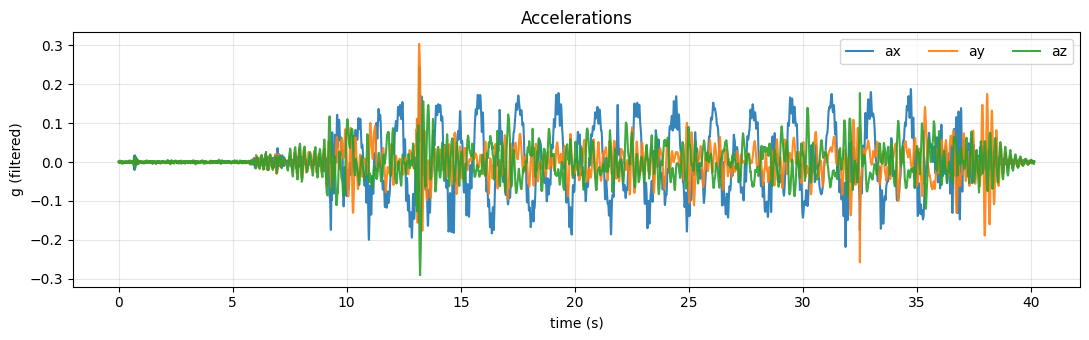

In [3]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(t, df["ax"], label="ax", alpha=0.9)
ax.plot(t, df["ay"], label="ay", alpha=0.9)
ax.plot(t, df["az"], label="az", alpha=0.9)
ax.set_xlabel("time (s)")
ax.set_ylabel("g (filtered)")
ax.set_title("Accelerations")
ax.legend(loc="upper right", ncol=3)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 3. Magnitude and slope

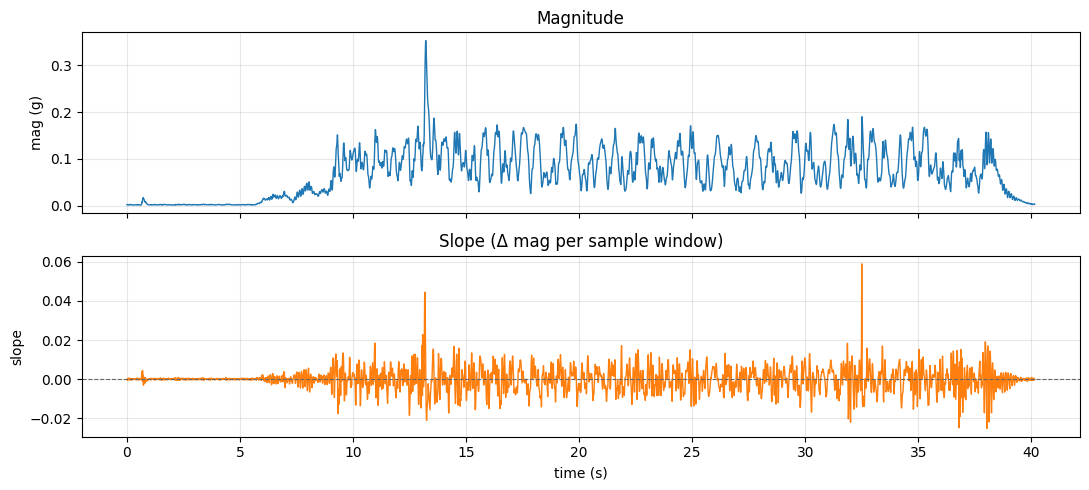

In [4]:
fig, (a0, a1) = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
a0.plot(t, df["mag"], color="C0", lw=1.0)
a0.set_ylabel("mag (g)")
a0.set_title("Magnitude")
a0.grid(True, alpha=0.3)

a1.plot(t, df["slope"], color="C1", lw=1.0)
a1.set_xlabel("time (s)")
a1.set_ylabel("slope")
a1.set_title("Slope (Δ mag per sample window)")
a1.axhline(0, color="0.4", ls="--", lw=0.8)
a1.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 4. Step Detection

Below, we mirror the step detection logic to attempt to visualize what would be counted as a step to help tune the oscillation tracker.

In [9]:
class Leg:
    SEEK_RISE = 0
    RISING = 1
    FALLING = 2


def detect_steps(df, slope_hyst: float, min_step_interval_s: float):
    """Offline replay of OscillationTracker.cpp (same hysteresis + interval gating).

    CSV `slope` matches firmware debug: row 0 is 0; row i>=1 is mag[i]-mag[i-1].
    Row 1 mirrors the firmware path that seeds `_prevSlope` / `_leg` without
    running peak or trough logic yet.
    """
    mag = df["mag"].to_numpy()
    slope = df["slope"].to_numpy()
    t = df["timestampUs"].to_numpy() * 1e-6

    events = []
    prev_slope = slope[0]
    leg = Leg.SEEK_RISE
    last_emit_t = -1e9
    step_idx = 0

    n = len(df)
    peaks = np.zeros(n)
    emitted = np.zeros(n)
    rejected = np.zeros(n)
    state_trace = np.zeros(n, dtype=np.int32)

    if n == 0:
        return np.asarray(events, dtype=object), peaks, emitted, rejected, state_trace

    state_trace[0] = Leg.SEEK_RISE
    if n < 2:
        return np.asarray(events, dtype=object), peaks, emitted, rejected, state_trace

    for i in range(1, n):
        s_curr = slope[i]

        # Second processed sample: firmware only seeds _prevSlope / leg (no switch).
        if i == 1:
            prev_slope = s_curr
            if s_curr >= slope_hyst:
                leg = Leg.RISING
            state_trace[i] = leg
            continue

        s_prev = prev_slope

        if leg == Leg.SEEK_RISE:
            if s_curr >= slope_hyst:
                leg = Leg.RISING

        elif leg == Leg.RISING:
            if (s_prev > 0 and s_curr < 0) and (
                s_prev >= slope_hyst or -s_curr >= slope_hyst
            ):
                peaks[i] = 1
                if (t[i] - last_emit_t) >= min_step_interval_s:
                    emitted[i] = 1
                    events.append((t[i], step_idx, mag[i]))
                    step_idx += 1
                    last_emit_t = t[i]
                else:
                    rejected[i] = 1
                leg = Leg.FALLING

        elif leg == Leg.FALLING:
            if (s_prev < 0) and (s_curr >= slope_hyst):
                leg = Leg.RISING

        state_trace[i] = leg
        prev_slope = s_curr

    return np.asarray(events, dtype=object), peaks, emitted, rejected, state_trace

In [ ]:
SLOPE_HYST = 0.0045
MIN_STEP_INTERVAL_S = 0.3

events, peaks, emitted, rejected, state_trace = detect_steps(df, SLOPE_HYST, MIN_STEP_INTERVAL_S)

print(f"Detected steps: {len(events)}")

Detected steps: 22


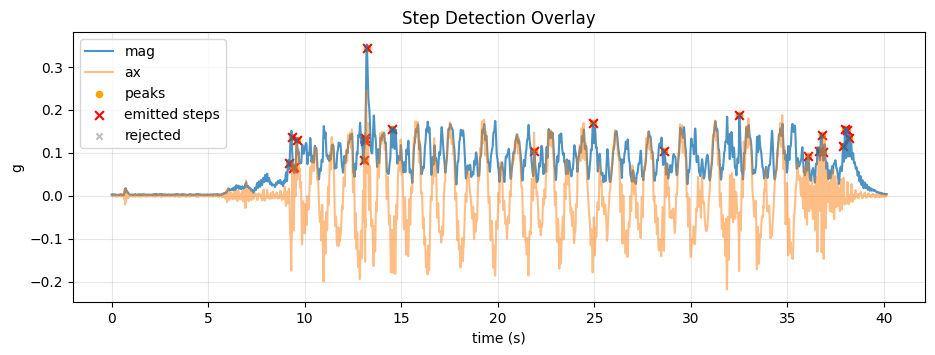

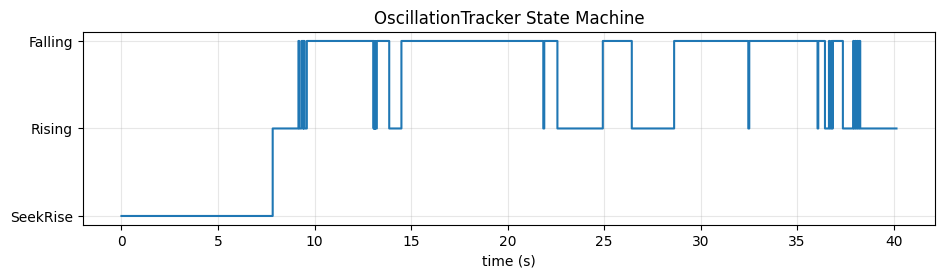

In [35]:
fig, ax = plt.subplots(figsize=(11, 3.5))

ax.plot(t, df["mag"], label="mag", alpha=0.8)
ax.plot(t, df["ax"], label="ax", alpha=0.5)

ax.scatter(
    t[peaks.astype(bool)],
    df["mag"][peaks.astype(bool)],
    color="orange",
    label="peaks",
    s=20,
)

ax.scatter(
    t[emitted.astype(bool)],
    df["mag"][emitted.astype(bool)],
    color="red",
    label="emitted steps",
    s=40,
    marker="x",
)

ax.scatter(
    t[rejected.astype(bool)],
    df["mag"][rejected.astype(bool)],
    color="gray",
    label="rejected",
    s=20,
    alpha=0.5,
    marker="x",
)

ax.set_title("Step Detection Overlay")
ax.set_xlabel("time (s)")
ax.set_ylabel("g")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

fig2, ax_sm = plt.subplots(figsize=(11, 2.5))
ax_sm.step(t, state_trace, where="post")
ax_sm.set_yticks([0, 1, 2])
ax_sm.set_yticklabels(["SeekRise", "Rising", "Falling"])
ax_sm.set_title("OscillationTracker State Machine")
ax_sm.set_xlabel("time (s)")
ax_sm.grid(True, alpha=0.3)

plt.show()

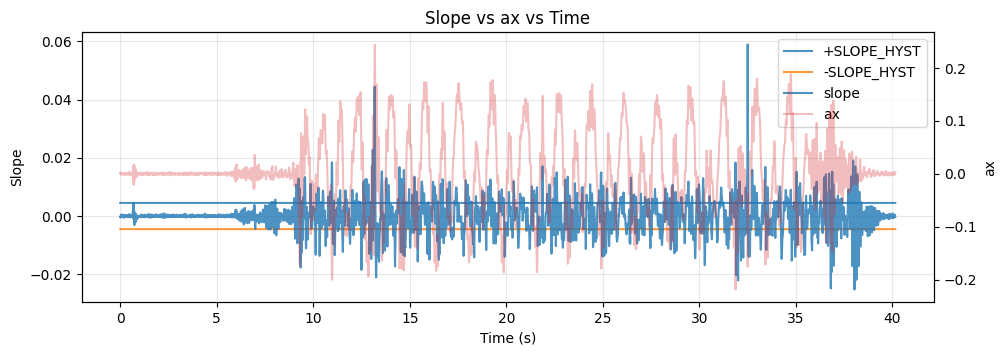

In [36]:
fig, ax1 = plt.subplots(figsize=(11, 3.5))

ax1.plot(t, [SLOPE_HYST]*len(t), label="+SLOPE_HYST", alpha=0.8)
ax1.plot(t, [-SLOPE_HYST]*len(t), label="-SLOPE_HYST", alpha=0.8)
ax1.plot(t, df["slope"], label="slope", alpha=0.8, color="tab:blue")

ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Slope")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(t, df["ax"], label="ax", alpha=0.3, color="tab:red")
ax2.set_ylabel("ax")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

ax1.set_title("Slope vs ax vs Time")

plt.show()